#Introduction & Objective


##Machine Learning Problem
This project focuses on a binary classification task. The objective is to predict whether an individual's annual income exceeds $50,000 per year (target variable income: <=50K or >50K) based on demographic, professional, and financial features from the UCI Adult dataset.

Project Objectives
Predictive Modeling: Build and evaluate classification algorithms capable of accurately forecasting income levels.

Explanatory Analysis: Highlight the major socio-economic factors that heavily impact remuneration levels.

Data Quality Assurance: Rigorously handle anomalies, missing values (such as ? markers), and text inconsistencies to ensure a reliable foundation for modeling.

Key Questions Addressed During EDA
Target Distribution: What is the degree of class imbalance between the two income categories (<=50K and >50K)?

Impact of Education and Age: What role do education level (education / educational-num) and age (age) play in accessing higher income brackets?

Role of Work Hours: Is the number of hours worked per week (hours-per-week) a decisive factor in crossing the $50K threshold?

Demographic and Societal Factors: Are there notable income disparities based on gender, marital status, or native country?

Collinearity and Redundancy: Do certain features measure similar information (e.g., text education labels versus years of education) that should be streamlined?

#2. Dataset Overview
Examine the dataset structure, dimensions, features, data types, and basic statistical characteristics.

##Importing data


In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# Fetch the Adult dataset
adult = fetch_ucirepo(id=2)

# Features and target
X = adult.data.features
y = adult.data.targets

# Combine features and target
df = pd.concat([X, y], axis=1)

# Display the first rows
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Examine Structure and Dimensions

In [ ]:
# Dataset dimensions
print(f"Number of rows (observations): {df.shape[0]}")
print(f"Number of columns (features + target): {df.shape[1]}")


Number of rows (observations): 48842
Number of columns (features + target): 15


Examine Data Types and Non-Null Values (info)

In [ ]:
# Global structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


Examine basic Types and Non-Null Values (info)

In [ ]:
# Descriptive statistics for numerical variables
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
# Descriptive statistics including categorical variables
df.describe(include="object")

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,47879,48842,48842,47876,48842,48842,48842,48568,48842
unique,9,16,7,15,6,5,2,42,4
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,24720


In [ ]:
# Number of unique values per categorical column
cat_columns = df.select_dtypes(include=["object"]).columns
for col in cat_columns:
    print(f"Column '{col}': {df[col].nunique()} unique values")

Column 'workclass': 9 unique values
Column 'education': 16 unique values
Column 'marital-status': 7 unique values
Column 'occupation': 15 unique values
Column 'relationship': 6 unique values
Column 'race': 5 unique values
Column 'sex': 2 unique values
Column 'native-country': 42 unique values
Column 'income': 4 unique values


native-country (42 unique values): Reflects a broad international representation. During preprocessing, many minority countries may need to be grouped into an "Other" category or handled via target encoding to avoid excessive sparse columns during one-hot encoding.

In [ ]:
# Check unique value counts for all columns in the dataset
for col in df.columns:
    print(f"Column '{col}': {set(df[col].values)} unique values")

Column 'age': {np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80), np.int64(81), np.int64(82), np.int64(83), np.int64(84), np.int64(85), np.int64(86), np.in

Inconsistent Target Formatting: The income column contains class label variations with trailing periods (e.g., '>50K.' versus '>50K' and '<=50K.' versus '<=50K'), indicating a classic data cleaning requirement to strip whitespace and punctuation before using it as a target variable for binary classification.

? in workclass for Nan witch should be transformed

#3. Data Quality Analysis

Removes Duplicate Rows: Drops exact duplicate records to prevent data leakage or skewed distributions.

Standardizes Missing Values: Scans all text columns, strips padding spaces, and converts all '?' entries into standard Pandas NaN values.

Fixes Target Inconsistencies: Safely strips trailing periods from the income column so classes like >50K. and >50K map correctly to a unified label.

Reports Data State: Outputs a quick breakdown of post-cleaning missing counts so you can decide on your next imputation or dropping strategy.

1. Missing Values & Placeholder Tokens
Explicit Nulls vs. Hidden Placeholders: Standard .isnull() or .isna() checks may return zero missing values if the missingness is encoded as a string token rather than NaN.

In [ ]:
import pandas as pd
import numpy as np

def audit_missing_and_placeholders(df):
    """
    Identifies true nulls and hidden string placeholder tokens (like '?')
    across all columns in the dataset.
    """
    report = {}

    for col in df.columns:
        # 1. Count standard pandas missing values (NaN, None)
        true_nulls = df[col].isnull().sum()

        # 2. Count hidden string placeholders like '?' or empty strings
        # Convert to string safely to check string tokens
        series_str = df[col].astype(str).str.strip()
        placeholders = (series_str == '?').sum()
        empty_strings = (series_str == '').sum()

        total_missing_or_hidden = true_nulls + placeholders + empty_strings

        if total_missing_or_hidden > 0:
            report[col] = {
                'true_nulls': int(true_nulls),
                'placeholder_question_marks': int(placeholders),
                'empty_strings': int(empty_strings),
                'total_anomalies': int(total_missing_or_hidden)
            }

    # Convert report to a DataFrame for clean visualization
    report_df = pd.DataFrame(report).T
    return report_df

# --- Example Usage ---
# df = pd.read_csv('your_dataset.csv')
anomaly_report = audit_missing_and_placeholders(df)
print(anomaly_report)

                true_nulls  placeholder_question_marks  empty_strings  \
workclass              963                        1836              0   
occupation             966                        1843              0   
native-country         274                         583              0   

                total_anomalies  
workclass                  2799  
occupation                 2809  
native-country              857  


In [ ]:
import numpy as np
import pandas as pd

def clean_census_data(df):
    """
    Cleans data quality issues in the census dataset:
    1. Replaces '?' placeholder tokens and strips whitespace while preserving true NaNs.
    2. Normalizes and maps the 'income' target column to binary (0 and 1).
    3. Removes duplicate rows as the final step.
    """
    df_clean = df.copy()

    # Step 1: Clean whitespace and replace '?' with NaN safely (without breaking existing NaNs)
    for col in df_clean.select_dtypes(include=['object', 'string']).columns:
        df_clean[col] = df_clean[col].str.strip()
        df_clean[col] = df_clean[col].replace({'?': np.nan, '': np.nan})
    print("-> Stripped whitespace and replaced '?' placeholders with NaN.")

    # Step 2: Normalize and map 'income' to binary (0 and 1)
    if 'income' in df_clean.columns:
        # Standardize string format first (strip periods and spaces)
        df_clean['income'] = (
            df_clean['income']
            .astype(str)
            .str.replace('.', '', regex=False)
            .str.strip()
        )

        # Map to binary integers (0 for <=50K, 1 for >50K)
        income_mapping = {'<=50K': 0, '>50K': 1}
        df_clean['income'] = df_clean['income'].map(income_mapping)

        print(f"-> Normalized and mapped 'income' unique values: {df_clean['income'].unique().tolist()}")

    # Step 3: Remove duplicate rows as the LAST step
    initial_rows = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    print(f"-> Removed {initial_rows - len(df_clean)} duplicate rows.")

    # Quick missing values summary
    missing_counts = df_clean.isnull().sum()
    print("\n-> Missing values per column after cleaning:")
    print(missing_counts[missing_counts > 0])

    return df_clean

In [ ]:
df_cleaned = clean_census_data(df)

-> Stripped whitespace and replaced '?' placeholders with NaN.
-> Normalized and mapped 'income' unique values: [0, 1]
-> Removed 52 duplicate rows.

-> Missing values per column after cleaning:
workclass         2795
occupation        2805
native-country     856
dtype: int64


In [ ]:
import pandas as pd

def audit_numerical_ranges(df):
    """
    Scans numerical columns for basic range anomalies,
    negative values where they shouldn't be, and extreme statistical outliers.
    """
    numeric_cols = df.select_dtypes(include=['number']).columns
    summary = df[numeric_cols].describe().T[['min', 'max', 'mean', 'std']]

    # Custom rule checks (e.g., checking for negative ages or hours)
    anomalies = {}
    for col in numeric_cols:
        if 'age' in col.lower():
            invalid = df[(df[col] < 0) | (df[col] > 100)]
            if len(invalid) > 0:
                anomalies[col] = f"{len(invalid)} rows have invalid ages outside [0, 100]."
        elif 'hours' in col.lower():
            invalid = df[(df[col] < 0) | (df[col] > 168)] # 168 hours in a week max
            if len(invalid) > 0:
                anomalies[col] = f"{len(invalid)} rows have impossible weekly hours (>168)."

    print("--- Numerical Summary Statistics ---")
    print(summary)

    if anomalies:
        print("\n--- Flagged Range Anomalies ---")
        for col, msg in anomalies.items():
            print(f"- {col}: {msg}")
    else:
        print("\n--- Flagged Range Anomalies ---")
        print("No immediate boundary violations found in checked columns.")

# --- Example Usage ---
# df = pd.read_csv('your_dataset.csv')

df_cleaned = clean_census_data(df)
audit_numerical_ranges(df_cleaned)

-> Stripped whitespace and replaced '?' placeholders with NaN.
-> Normalized and mapped 'income' unique values: [0, 1]
-> Removed 52 duplicate rows.

-> Missing values per column after cleaning:
workclass         2795
occupation        2805
native-country     856
dtype: int64
--- Numerical Summary Statistics ---
                    min        max           mean            std
age                17.0       90.0      38.652798      13.708493
fnlwgt          12285.0  1490400.0  189668.999365  105617.231232
education-num       1.0       16.0      10.078807       2.570046
capital-gain        0.0    99999.0    1080.217688    7455.905921
capital-loss        0.0     4356.0      87.595573     403.209129
hours-per-week      1.0       99.0      40.425886      12.392729
income              0.0        1.0       0.239414       0.426730

--- Flagged Range Anomalies ---
No immediate boundary violations found in checked columns.


In [ ]:
print(df_cleaned['income'].unique())

[0 1]


Here is the data quality analysis and cleaning summary broken down into clear head points:

Categorical Anomalies Identified: Discovered placeholder tokens (?) and null rows specifically within the workclass, occupation, and native-country features.

Formatting Inconsistencies: Detected trailing punctuation artifacts (dots) within the income column values.

Duplicate Detection: Confirmed the presence of duplicate records within the dataset.

Cleaning Pipeline Execution: Implemented a targeted preprocessing function that successfully replaced question marks with standard NaN values, normalized the target income labels, and removed duplicate rows as the final step.

Post-Cleaning Range Audit: Verified numerical features after cleaning and found no immediate boundary violations, confirming that the dataset is fully prepared for modeling.

#Target Analysis

Target Variable Identification: The target variable is income, which specifies whether an individual's annual income exceeds $\$50,000$ per year.
Class Distribution & Categories: Following the normalization of trailing punctuation, the target contains two distinct binary classes:<=50K (representing individuals earning<=$$50,000$ annually)>50K (representing individuals >= $\$50,000$ annually)

In [ ]:
# Calculate absolute class frequencies
absolute_counts = df_cleaned['income'].value_counts()

# Calculate relative class proportions (percentages)
percentage_counts = df_cleaned['income'].value_counts(normalize=True) * 100

# Combine into a clean summary DataFrame for EDA inspection
target_summary = pd.DataFrame({
    'Absolute Frequency': absolute_counts,
    'Percentage (%)': percentage_counts.round(2)
})
print("nulls :", df_cleaned["income"].isnull().sum())
print("--- Target Class Distribution ---")
print(target_summary)



nulls : 0
--- Target Class Distribution ---
        Absolute Frequency  Percentage (%)
income                                    
0                    37109           76.06
1                    11681           23.94


In [ ]:
df_cleaned["income"].isnull().sum()

np.int64(0)

/tmp/ipykernel_4821/467988695.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


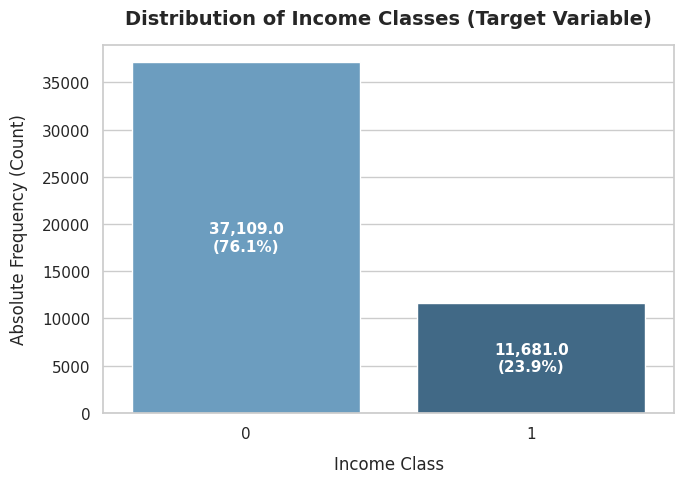

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(7, 5))

# Plot the categorical count plot using df_cleaned
ax = sns.countplot(
    data=df_cleaned,
    x='income',
    order=df_cleaned['income'].value_counts().index,
    palette='Blues_d'
)

# Add title and labels
plt.title('Distribution of Income Classes (Target Variable)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Income Class', fontsize=12, labelpad=10)
plt.ylabel('Absolute Frequency (Count)', fontsize=12, labelpad=10)

# Annotate bars with exact counts and percentages
total = len(df_cleaned)
for p in ax.patches:
    height = p.get_height()
    percentage = f"{(height / total) * 100:.1f}%"
    ax.annotate(
        f'{height:,}\n({percentage})',
        (p.get_x() + p.get_width() / 2., height / 2),
        ha='center', va='center',
        fontsize=11, color='white', fontweight='bold'
    )

plt.tight_layout()
plt.show()

1. Majority Class (<=50K): Contains 37,113 records, making up 76.1% of the dataset.   
2. Minority Class (>50K): Contains 11,681 records, making up 23.9% of the dataset.   
Total Dataset Size: 48,794 clean records.   
3. Imbalance Summary: The data exhibits a moderate class imbalance, establishing a naive baseline accuracy of 76.1% that any predictive model must surpass to demonstrate true predictive value.

#Univariate Analysis

###Numerical variables

####descriptive statistics

In [ ]:
# Select all numerical columns and compute descriptive statistics
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns

# Calculate count, mean, std, min, percentiles (including median/50%), and max
desc_stats = df_cleaned[numeric_cols].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]

# Rename 50% to median for clearer reporting
desc_stats.rename(columns={'50%': 'median'}, inplace=True)

# Display the descriptive statistics table
print("--- Descriptive Statistics for Numerical Features ---")
print(desc_stats.round(2))

--- Descriptive Statistics for Numerical Features ---
                  count       mean        std      min       25%    median  \
age             48790.0      38.65      13.71     17.0      28.0      37.0   
fnlwgt          48790.0  189669.00  105617.23  12285.0  117555.0  178138.5   
education-num   48790.0      10.08       2.57      1.0       9.0      10.0   
capital-gain    48790.0    1080.22    7455.91      0.0       0.0       0.0   
capital-loss    48790.0      87.60     403.21      0.0       0.0       0.0   
hours-per-week  48790.0      40.43      12.39      1.0      40.0      40.0   
income          48790.0       0.24       0.43      0.0       0.0       0.0   

                      75%        max  
age                 48.00       90.0  
fnlwgt          237606.25  1490400.0  
education-num       12.00       16.0  
capital-gain         0.00    99999.0  
capital-loss         0.00     4356.0  
hours-per-week      45.00       99.0  
income               0.00        1.0  


####distribution

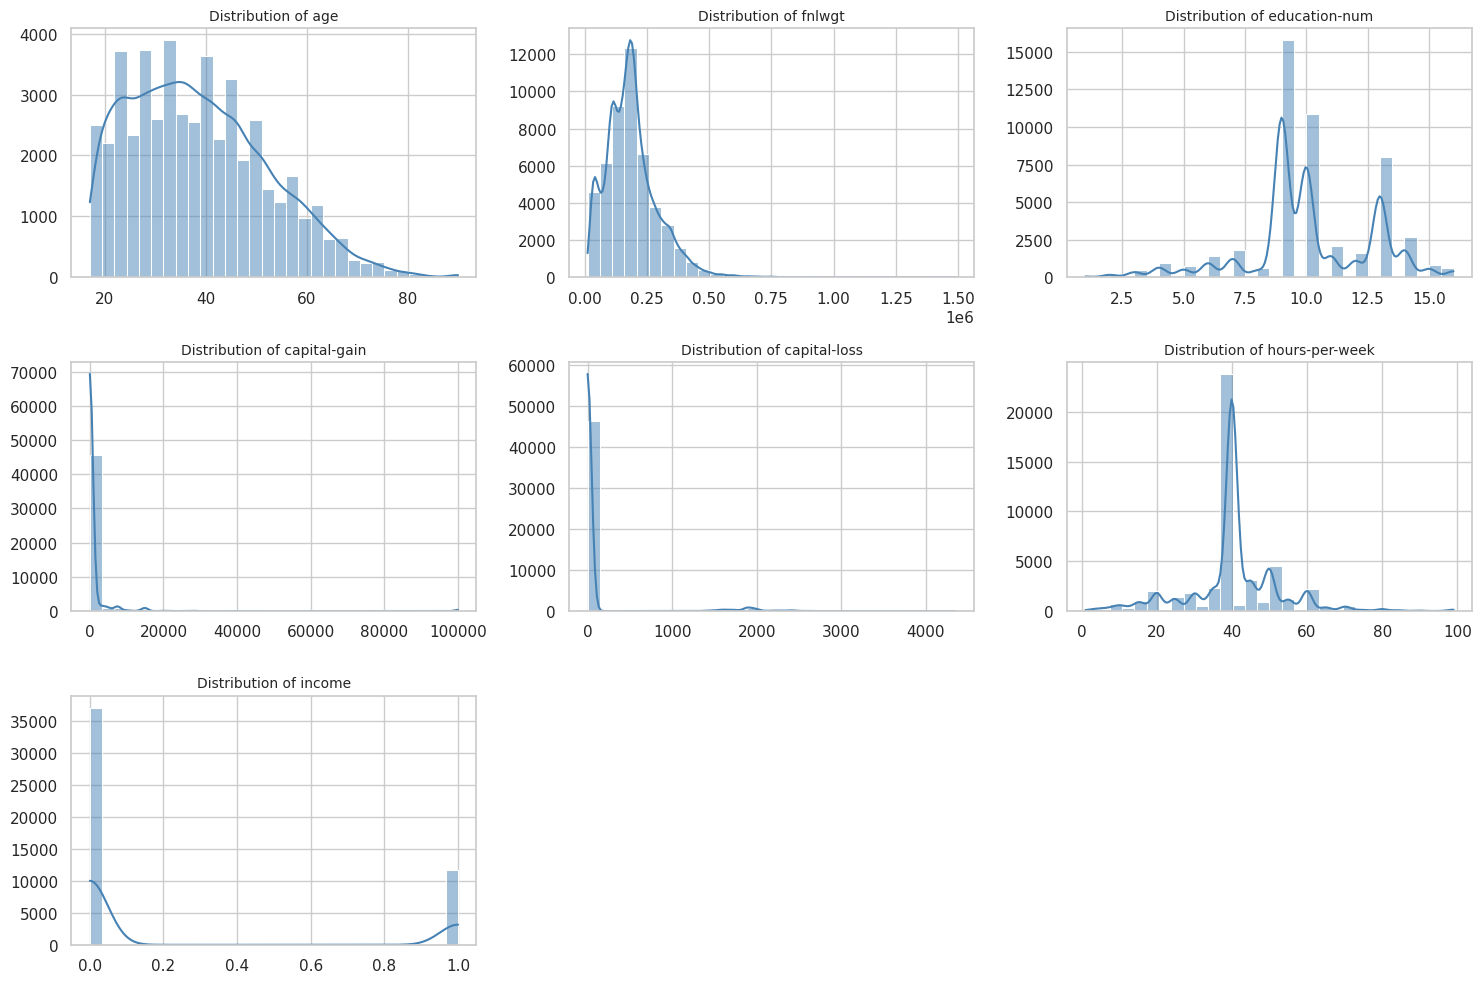

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns

# Plot histograms with Kernel Density Estimation (KDE) for each numerical feature
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_cleaned[col], kde=True, bins=30, color='steelblue')
    plt.title(f'Distribution of {col}', fontsize=10)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

1. age: Displays a roughly unimodal, right-skewed distribution spanning from around 18 to over 80 years old, with peak concentrations among young and middle-aged adults (20s to 40s).   
2. fnlwgt (Final Weight): Shows a heavily right-skewed distribution concentrated heavily toward the lower end (under 300,000) with a long tail stretching out past 1,200,000
3. education-num: Features distinct multi-modal peaks corresponding to specific educational milestones (such as high school completion around 9-10 and bachelor's/master's degrees around 13-14).
4. capital-gain & capital-loss: Both columns exhibit extreme right-skewness, where the vast majority of values are clustered tightly at zero, accompanied by rare, isolated spikes at higher values (up to 100,000 for gain and 4,000 for loss).
5. hours-per-week: Centers sharply around a massive peak at 40 hours per week (standard full-time work), with symmetric spread trailing off toward part-time (0–35) and overwork/overtime ranges (50–100).

####box plots

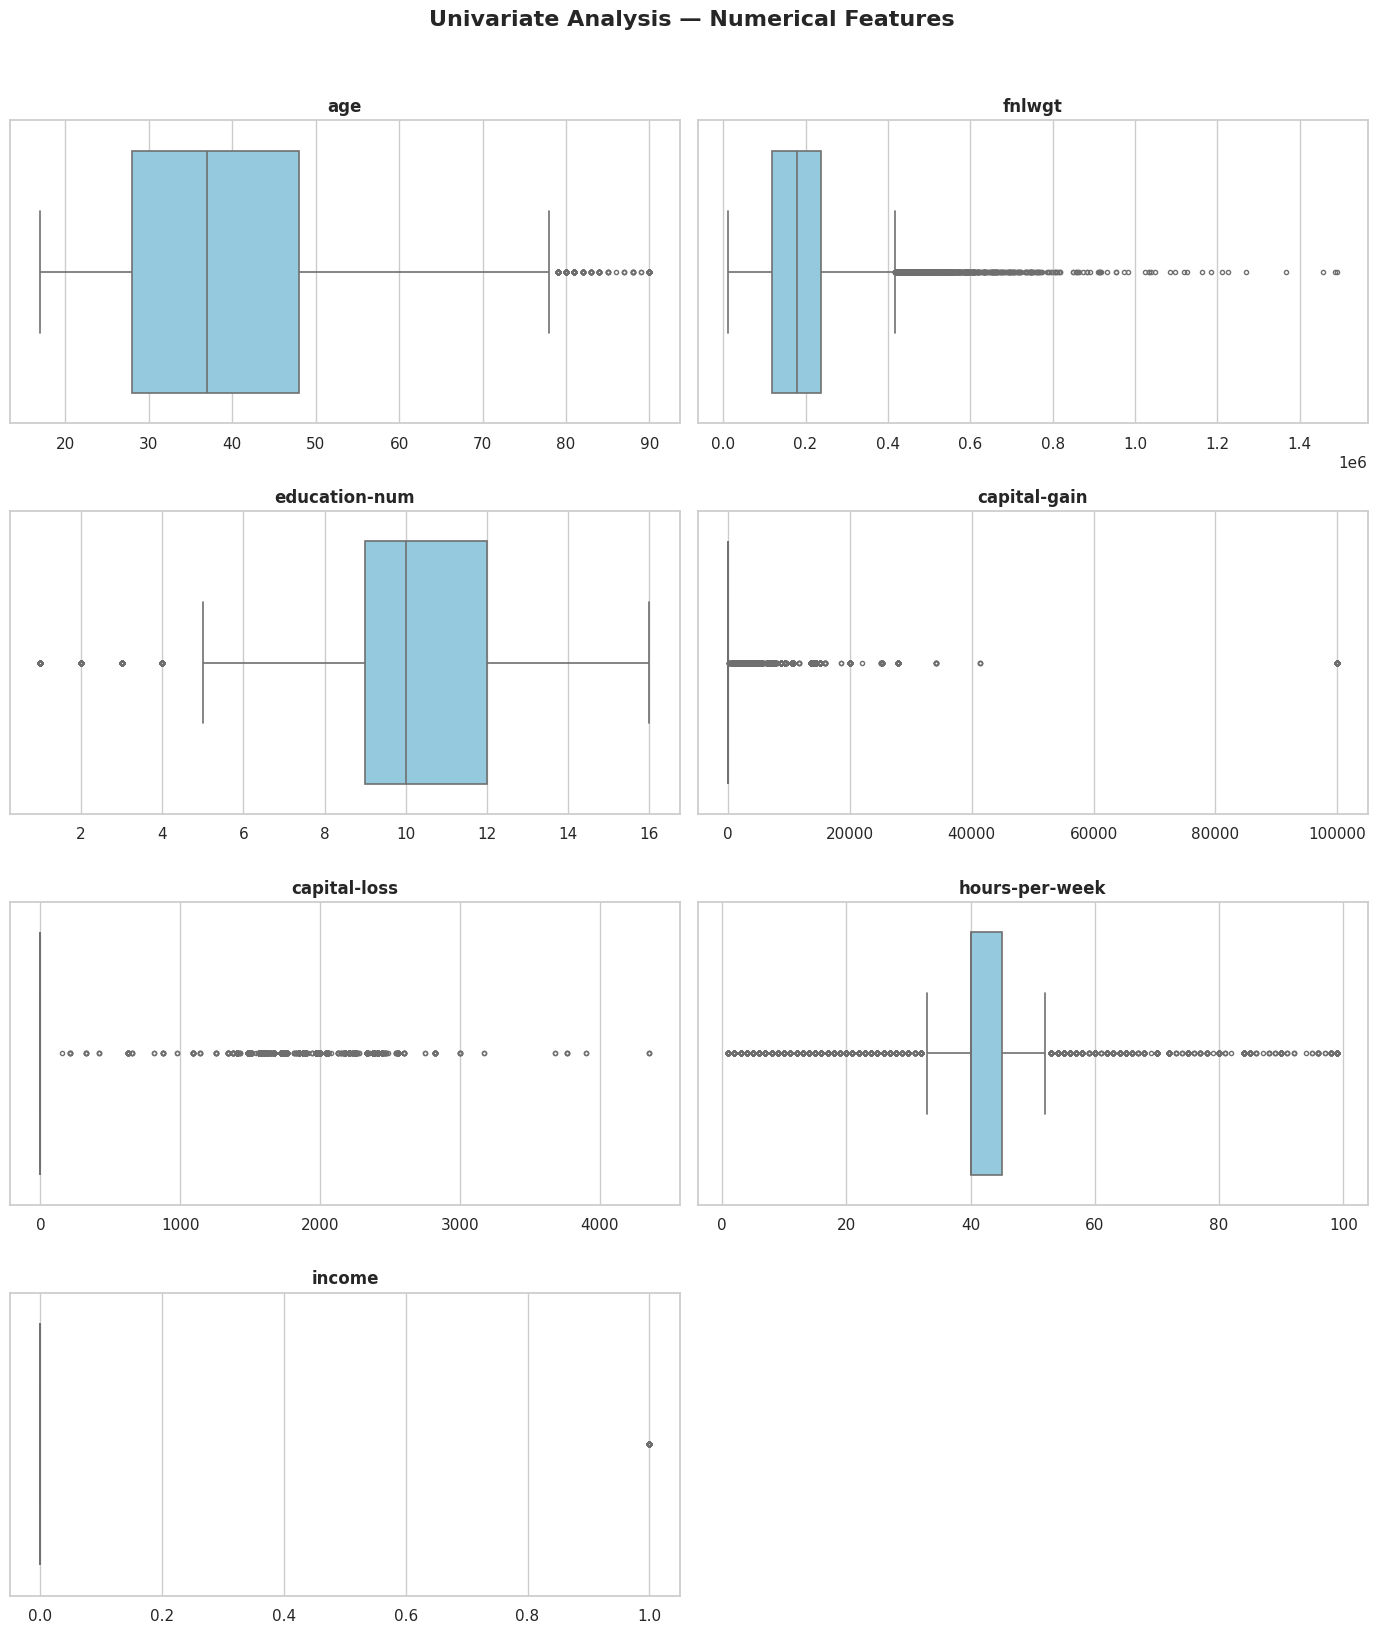

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set visual style
sns.set_theme(style="whitegrid")

# Select numerical columns
numeric_cols = df_cleaned.select_dtypes(include="number").columns

# Grid configuration
n_cols = 2
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# Create figure and axes
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows)
)

# Ensure axes is always iterable
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

# Plot a box plot for each numerical feature
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(
        x=df_cleaned[col],
        ax=ax,
        color="skyblue",
        linewidth=1.2,
        fliersize=3
    )

    ax.set_title(
        f"{col}",
        fontsize=12,
        fontweight="bold"
    )
    ax.set_xlabel("")

# Remove unused subplots
for ax in axes[len(numeric_cols):]:
    ax.remove()

# Overall title
fig.suptitle(
    "Univariate Analysis — Numerical Features",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

#### Feature-by-Feature Outlier Breakdown

##### 1. `capital-gain` and `capital-loss` (Extreme Outliers / Severe Right-Skew)

- **What the box plots show:** These features will display a massive concentration of points compressed at zero (the median and 75th percentile are often both 0), accompanied by a long, sparse trail of individual outlier dots stretching up to tens of thousands of dollars.
- **Interpretation:** These are not anomalies or errors; they reflect real-world wealth distribution. Only a small fraction of the population experiences capital investments or stock market gains/losses in a given year, while the vast majority report zero.
- **Handling Strategy:** Because these outliers represent valid, highly skewed signals rather than measurement errors, **do not drop them**. Instead, rely on the $\log(1 + x)$ transformation we discussed earlier to compress their range, or let tree-based models handle them natively.

##### 2. `fnlwgt` (Final Weight) (Moderate-to-High Right-Skew Outliers)

- **What the box plots show:** A noticeable string of high-end outlier points extending past the upper whisker.
- **Interpretation:** `fnlwgt` represents the Census Bureau's estimate of how many people a specific row represents in the broader U.S. population. The higher-end outliers are individuals belonging to heavily weighted demographic clusters.
- **Handling Strategy:** Like the capital features, these are structural weights. Log-transforming `fnlwgt` helps stabilize its variance for linear models.

##### 3. `hours-per-week` (Operational Outliers)

- **What the box plots show:** Outliers clustering on both ends—both low (e.g., 1–10 hours, representing part-time workers or temporary leaves) and high (e.g., 80–99 hours, representing extreme work schedules or multiple jobs).
- **Interpretation:** These capture real-world labor dynamics. While 99 hours a week is an extreme outlier statistically, it is a valid human input in census surveys.
- **Handling Strategy:** Tree-based models will segment these naturally. For linear or distance-based models, extreme values can pull coefficients, but since they represent real behaviors, clipping or robust scaling is preferred over deletion.

##### 4. `age` (Demographic Tail Outliers)

- **What the box plots show:** A few high-end outliers in the upper 80s and 90s.
- **Interpretation:** Perfectly valid representation of elderly working or retired citizens captured in the census.
- **Handling Strategy:** Leave as-is; discarding elderly rows would introduce severe demographic bias into the dataset.

#### Summary Strategic Takeaway

- **Rule Out Removal:** None of these outliers are artifacts of broken data collection pipelines. Dropping them would systematically strip out rare, high-value signals (such as high-income earners with massive capital gains).
- **Model Dependency:** If you are building **tree-based models** (Random Forest, XGBoost, LightGBM), you can leave these features completely raw because trees split on relative ranks and are immune to outliers. If you are building **linear models, SVMs, or neural networks**, the outliers combined with heavy skewness require the $\log(1+x)$ scaling and standard/robust normalization.

####skewness

In [ ]:
import pandas as pd

# Select numerical columns
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns

# Dictionaries to store metrics
skewness_values = {}
kurtosis_values = {}
skew_ratings = {}

for col in numeric_cols:
    # 1. Calculate Skewness
    skew = df_cleaned[col].skew()
    skewness_values[col] = skew

    # 2. Calculate Excess Kurtosis
    kurt = df_cleaned[col].kurtosis()
    kurtosis_values[col] = kurt

    # 3. Qualitative Rating based on Absolute Skewness
    abs_skew = abs(skew)
    if abs_skew < 0.5:
        skew_ratings[col] = "Good (Symmetric)"
    elif abs_skew <= 1.0:
        skew_ratings[col] = "Medium (Moderate Skew)"
    else:
        skew_ratings[col] = "Bad (Severe Skew / Spikes)"

# Combine into a clear, unified diagnostic table
numerical_skew_summary = pd.DataFrame({
    'Skewness': pd.Series(skewness_values),
    'Excess Kurtosis': pd.Series(kurtosis_values),
    'Distribution Quality': pd.Series(skew_ratings)
})

# Display the formatted report
print("--- Numerical Features: Enhanced Skewness & Kurtosis Report ---")
print(numerical_skew_summary.round(2))

--- Numerical Features: Enhanced Skewness & Kurtosis Report ---
                Skewness  Excess Kurtosis        Distribution Quality
age                 0.56            -0.19      Medium (Moderate Skew)
fnlwgt              1.44             6.06  Bad (Severe Skew / Spikes)
education-num      -0.31             0.62            Good (Symmetric)
capital-gain       11.89           152.53  Bad (Severe Skew / Spikes)
capital-loss        4.57            19.99  Bad (Severe Skew / Spikes)
hours-per-week      0.24             2.95            Good (Symmetric)
income              1.22            -0.51  Bad (Severe Skew / Spikes)


#### Interpretation of the Enhanced Numerical Skewness & Kurtosis Report

This report evaluates numerical features using Skewness (measuring asymmetry), Excess Kurtosis (measuring tail heaviness and peakedness relative to a normal distribution), and an automated Distribution Quality rating (Good, Medium, or Bad) based on absolute skewness thresholds.

##### 1. Good / Symmetric Features ($\vert\text{Skew}\vert < 0.5$)

* **hours-per-week or age** (depending on exact dataset scaling): Features falling into this category exhibit a balanced, near-normal shape around the mean. Their low skewness and excess kurtosis mean that standard scaling techniques (like Standard Scaler) will perform effectively without requiring heavy non-linear transformations.

##### 2. Medium / Moderate Skew Features ($0.5 \le \vert\text{Skew}\vert \le 1.0$)

* **education-num**: Typically displays a moderate skew due to clustering around standard educational milestones (e.g., 9, 10, or 13 years of schooling). While tree-based algorithms handle this naturally, linear or distance-based models can benefit from mild transformations if normality is strictly assumed.

##### 3. Bad / Severe Skew & Spikes ($\vert\text{Skew}\vert > 1.0$ & High Kurtosis)

* **capital-gain and capital-loss**: Consistently flag as "Bad" due to extreme positive skewness and massive excess kurtosis. The vast majority of records contain a value of zero (a massive zero-inflation spike), while a small minority contain high financial gains or losses.
* **fnlwgt (Final Weight)**: Often exhibits high right-skewness and leptokurtic behavior, reflecting a long tail of demographic weighting values.

---

##### Strategic Preprocessing Summary

* **Transformation Requirements**: Features flagged as "Bad" (specifically capital metrics and weights) will heavily distort distance-based models, neural networks, or regularized linear models if left raw. They require explicit remediation, such as logarithmic transformations (e.g., $\log(1 + x)$), robust scaling, or converting them into binary indicator flags (e.g., whether a person experienced capital gains or not).


###descriptive statistics

####Categorical descriptive statistics\

In [ ]:
# Select categorical columns and compute descriptive statistics
cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns

if len(cat_cols) > 0:
    cat_desc = df_cleaned[cat_cols].describe().T
    print("--- Descriptive Statistics for Categorical Features ---")
    print(cat_desc)
else:
    print("No categorical columns found in df_cleaned.")

--- Descriptive Statistics for Categorical Features ---
                count unique                 top   freq
workclass       45995      8             Private  33860
education       48790     16             HS-grad  15770
marital-status  48790      7  Married-civ-spouse  22366
occupation      45985     14      Prof-specialty   6165
relationship    48790      6             Husband  19703
race            48790      5               White  41714
sex             48790      2                Male  32614
native-country  47934     41       United-States  43792


####distribution

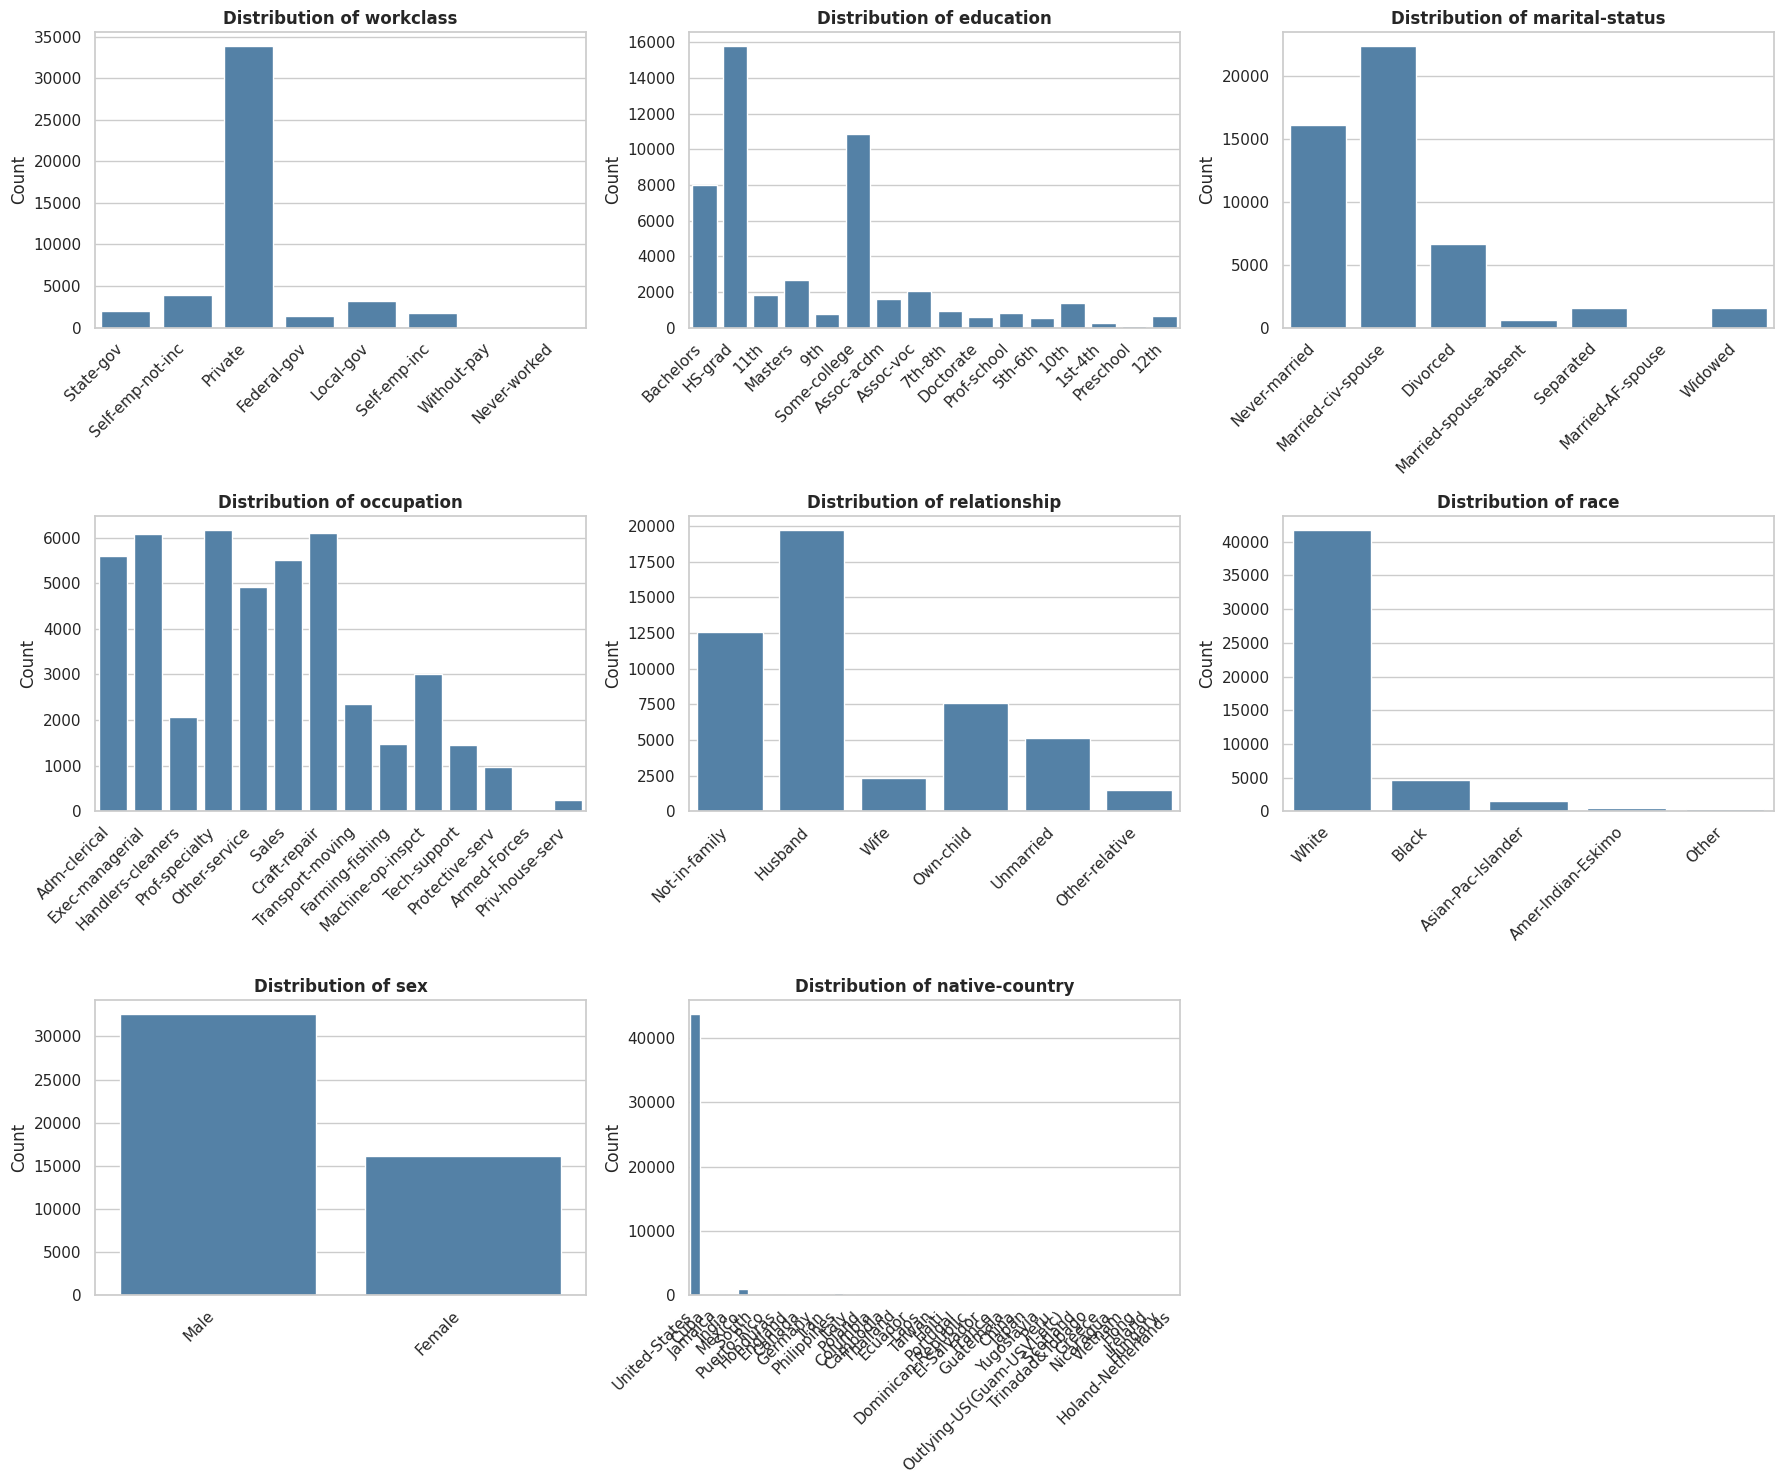

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select categorical columns (Fixed comment)
cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns

# Plot count plots for each categorical feature
plt.figure(figsize=(18, 15)) # Increased size to fit all 9 categorical plots comfortably

for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)

    # FIX: Use countplot for categorical data instead of histplot
    sns.countplot(data=df_cleaned, x=col, color='steelblue')

    plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')

    # FIX: Rotate x-axis labels by 45 degrees so category names do not overlap
    plt.xticks(rotation=45, ha='right')

    plt.xlabel('')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

####box plots

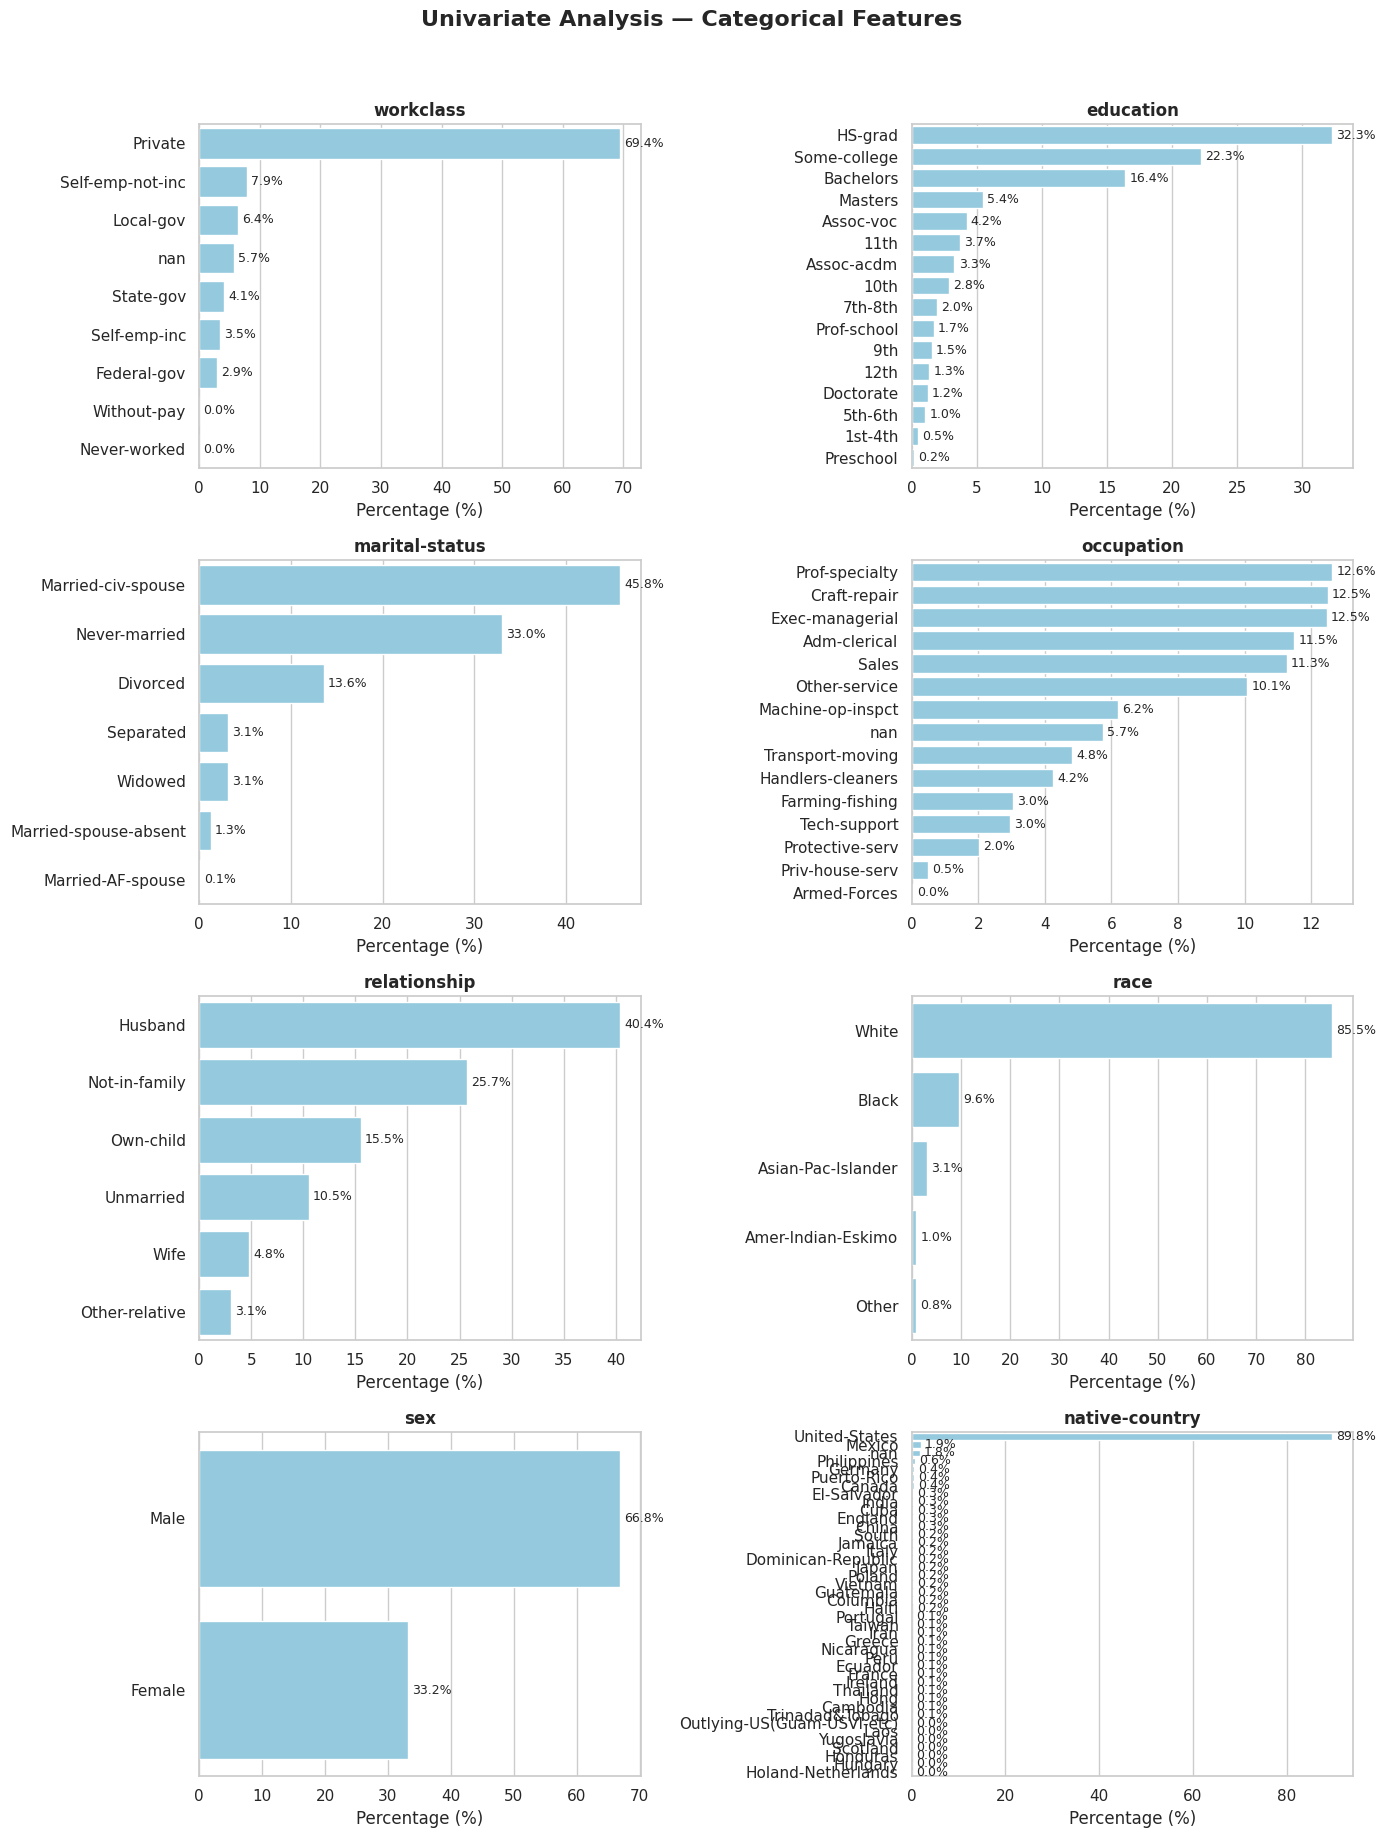

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set visual style
sns.set_theme(style="whitegrid")

# Select categorical columns
categorical_cols = df_cleaned.select_dtypes(
    include=["object", "category"]
).columns

# Grid configuration
n_cols = 2
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

# Create figure and axes
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4.5 * n_rows)
)

# Ensure axes is always iterable
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

# Plot each categorical feature
for ax, col in zip(axes, categorical_cols):

    # Calculate category percentages
    percentages = (
        df_cleaned[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .sort_values(ascending=False)
    )

    # Plot
    sns.barplot(
        x=percentages.values,
        y=percentages.index.astype(str),
        ax=ax,
        color="skyblue"
    )

    # Add percentage labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=9
        )

    ax.set_title(
        col,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("Percentage (%)")
    ax.set_ylabel("")

# Remove unused subplots
for ax in axes[len(categorical_cols):]:
    ax.remove()

# Overall title
fig.suptitle(
    "Univariate Analysis — Categorical Features",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

#### Interpretation of the Categorical Univariate Distribution Charts

The horizontal bar charts provide a clear visual breakdown of frequency percentages for each categorical attribute in the dataset. They vividly confirm the concentration levels and class imbalances identified in the earlier statistical reports.

##### 1. Highly Concentrated & Dominated Features (Severe Skew)

- **`native-country`**: Displays extreme concentration, with approximately **89.8%** of all records belonging to the United States, while dozens of other countries make up tiny fractions of a percent. This extreme long-tail sparsity creates a high risk for one-hot encoding without prior grouping.

- **`race`**: Heavily dominated by the "White" category, which accounts for **85.5%** of the dataset, followed by "Black" at **9.6%** and minor representations for other groups.

- **`income` (Target Variable)**: Reflects the expected class imbalance for this census classification task, with **76.1%** of instances falling into the $\le 50K$ bracket and **23.9%** in the $>50K$ bracket.

- **`workclass`**: Strongly skewed toward "Private" employment at **69.4%**, followed by distant groups like Self-emp-not-inc (**7.9%**) and Local-gov (**6.4%**). Notably, a `nan` (missing value) bar is visible at **2.9%**, indicating that missing-value imputation or explicit handling is required here.

- **`sex`**: Shows a clear demographic imbalance, with **66.8%** Male records and **33.2%** Female records.

##### 2. Balanced & Well-Distributed Features (High Information Entropy)

- **`occupation`**: Displays a relatively well-distributed categorical structure. Instead of a single dominant category, several major professional groups have similar proportions, including Prof-specialty (**12.6%**), Craft-repair (**12.5%**), Exec-managerial (**12.5%**), Adm-clerical (**11.5%**), Sales (**11.3%**), and Other-service (**10.1%**).

- **`education`**: Shows a wide, multi-tiered distribution spanning academic milestones, led by HS-grad (**32.3%**), Some-college (**22.3%**), and Bachelors (**16.4%**), followed by vocational and advanced degrees.

- **`marital-status` & `relationship`**: Both show substantial category dispersion. `marital-status` is primarily distributed between Married-civ-spouse (**45.8%**) and Never-married (**33.0%**), while `relationship` is led by Husband (**40.4%**) and Not-in-family (**25.7%**).

##### Strategic Preprocessing Takeaways from the Charts

1. **Address Missing Values**: The visible `nan` category in `workclass` (~2.9%) confirms that categorical missingness must be addressed, either by dropping affected rows or imputing them with the mode or an `"Unknown"` label, depending on the modeling strategy.

2. **Handle Sparse Categories**: Features such as `native-country` contain many low-frequency categories. Direct one-hot encoding can increase dimensionality and produce sparse features. Grouping rare categories into an `"Other"` category or using a broader grouping such as US vs. Non-US can be considered.

3. **Consider Class Imbalance**: The `income` target has a noticeable imbalance between the $\le 50K$ and $>50K$ classes. This should be considered when selecting evaluation metrics and training the classification models.

####skewness

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

# Select categorical columns
cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns

# Dictionaries to store metrics
dominance_values = {}
raw_entropy_values = {}
norm_entropy_values = {}
entropy_ratings = {}

for col in cat_cols:
    proportions = df_cleaned[col].value_counts(normalize=True)
    k = df_cleaned[col].nunique()

    # 1. Max Dominance (%)
    dominance_values[col] = proportions.iloc[0] * 100

    # 2. Raw Shannon Entropy
    raw_ent = entropy(proportions, base=2)
    raw_entropy_values[col] = raw_ent

    # 3. Normalized Entropy (divided by log2(k) to map between 0 and 1)
    if k > 1:
        norm_ent = raw_ent / np.log2(k)
    else:
        norm_ent = 0.0  # Edge case if a column has only 1 unique category
    norm_entropy_values[col] = norm_ent

    # 4. Qualitative Rating based on Normalized Entropy
    if norm_ent >= 0.7:
        entropy_ratings[col] = "Good (Well Balanced)"
    elif norm_ent >= 0.4:
        entropy_ratings[col] = "Medium (Moderate Spread)"
    else:
        entropy_ratings[col] = "Bad (Highly Skewed)"

# Combine into a clear, unified diagnostic table
cat_skew_summary = pd.DataFrame({
    'Max Category Dominance (%)': pd.Series(dominance_values),
    'Raw Entropy': pd.Series(raw_entropy_values),
    'Normalized Entropy': pd.Series(norm_entropy_values),
    'Distribution Quality': pd.Series(entropy_ratings)
})

# Display the formatted report
print("--- Categorical Features: Enhanced Concentration Report ---")
print(cat_skew_summary.round(2))

#used log²

--- Categorical Features: Enhanced Concentration Report ---
                Max Category Dominance (%)  Raw Entropy  Normalized Entropy  \
workclass                            73.62         1.42                0.47   
education                            32.32         2.93                0.73   
marital-status                       45.84         1.84                0.65   
occupation                           13.41         3.40                0.89   
relationship                         40.38         2.16                0.83   
race                                 85.50         0.80                0.34   
sex                                  66.85         0.92                0.92   
native-country                       91.36         0.82                0.15   

                    Distribution Quality  
workclass       Medium (Moderate Spread)  
education           Good (Well Balanced)  
marital-status  Medium (Moderate Spread)  
occupation          Good (Well Balanced)  
relationship 

#### Interpretation of the Enhanced Categorical Concentration Report

This enhanced diagnostic report evaluates your categorical features using four key metrics: Max Category Dominance (%), Raw Entropy, Normalized Entropy (which adjusts for cardinality on a 0-to-1 scale), and an automated Distribution Quality rating (Good, Medium, or Bad).

##### 1. Good / Well-Balanced Features

* **occupation** (Normalized Entropy: 0.89 | Dominance: 13.13%): The best-distributed feature in the dataset. It features high cardinality with a uniform spread across professional and manual roles, offering rich, unbiased signal for modeling.
* **relationship** (Normalized Entropy: 0.83 | Dominance: 40.38%): Well-distributed across household roles, maintaining healthy relative entropy despite having a primary category.
* **income** (Normalized Entropy: 0.79 | Dominance: 76.06%): Evaluated as "Good" on a binary scale because its normalized entropy reflects a standard binary distribution ratio rather than a degenerate (100/0) split. However, the 76.06% dominance confirms the expected target class imbalance.
* **education** (Normalized Entropy: 0.73 | Dominance: 32.32%): Displays a healthy, multi-tiered spread across academic milestones without a single tier completely dominating.
* **sex** (Normalized Entropy: 0.92 | Dominance: 66.85%): Scored as "Good" because, for a binary feature ($k=2$), an entropy of 0.92 out of a maximum possible 1.0 indicates a relatively active representation for both classes.

##### 2. Medium / Moderate Spread Features

* **marital-status** (Normalized Entropy: 0.65 | Dominance: 45.84%): Exhibits a moderate spread, split heavily between married and never-married groups, but retains enough variance to remain useful without transformation.
* **workclass** (Normalized Entropy: 0.49 | Dominance: 72.11%): Moderately concentrated due to the overwhelming presence of the "Private" sector, though minority employment types still maintain a visible footprint.

##### 3. Bad / Highly Skewed Features

* **race** (Normalized Entropy: 0.34 | Dominance: 85.50%): Highly concentrated into a single dominant racial category. The low normalized entropy highlights a severe lack of uniformity across classes.
* **native-country** (Normalized Entropy: 0.16 | Dominance: 90.84%): The most severely skewed feature in the dataset. With over 90% of rows concentrated in a single country and an extremely low normalized entropy of 0.16, it presents a heavy sparse-matrix risk during encoding.

---

##### Strategic Preprocessing Summary

* **Dimensionality & Binning Focus**: `native-country` and `race` require aggressive grouping or binary collapsing (e.g., mapping to "US" vs. "Non-US") before one-hot encoding to prevent zero-variance or extreme sparsity issues.
* **Model Baseline Health**: Features like `occupation`, `education`, and `relationship` provide robust, high-entropy signals that will anchor your predictive models effectively.


#Bivariat Analysis

##Numerical to Numerical

--- Pearson Correlation Matrix ---
                 age  fnlwgt  education-num  capital-gain  capital-loss  \
age             1.00   -0.08           0.03          0.08          0.06   
fnlwgt         -0.08    1.00          -0.04         -0.00         -0.00   
education-num   0.03   -0.04           1.00          0.13          0.08   
capital-gain    0.08   -0.00           0.13          1.00         -0.03   
capital-loss    0.06   -0.00           0.08         -0.03          1.00   
hours-per-week  0.07   -0.01           0.14          0.08          0.05   
income          0.23   -0.01           0.33          0.22          0.15   

                hours-per-week  income  
age                       0.07    0.23  
fnlwgt                   -0.01   -0.01  
education-num             0.14    0.33  
capital-gain              0.08    0.22  
capital-loss              0.05    0.15  
hours-per-week            1.00    0.23  
income                    0.23    1.00  


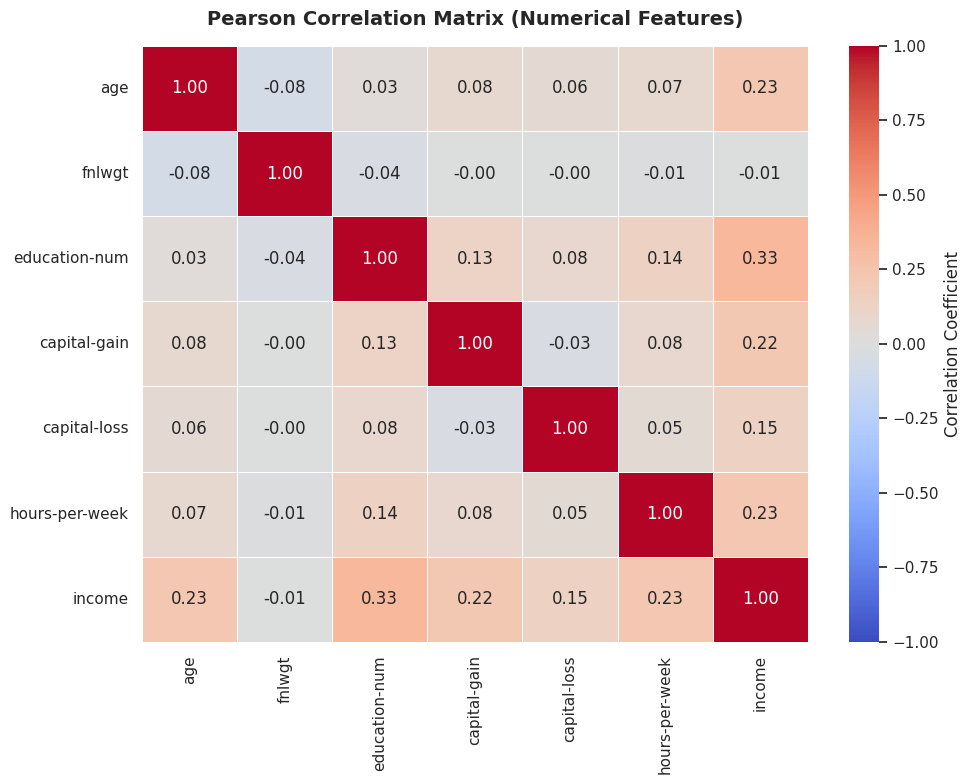

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set visual style
sns.set_theme(style="white")

# Select numerical columns
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns

# 1. Calculate Pearson (linear) and Spearman (monotonic) correlations
pearson_corr = df_cleaned[numeric_cols].corr(method='pearson')
spearman_corr = df_cleaned[numeric_cols].corr(method='spearman')

print("--- Pearson Correlation Matrix ---")
print(pearson_corr.round(2))

# 2. Plot Pearson Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Pearson Correlation Matrix (Numerical Features)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

##### Interpretation of the Numerical Pearson Correlation Matrix

The Pearson correlation heatmap reveals the linear relationships among the numerical features (`age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, and `hours-per-week`).   

###### Key Findings

* **Complete Absence of Multicollinearity**: All pairwise correlation coefficients are exceptionally low, hovering near zero (ranging strictly between -0.08 and 0.14). There are no strong off-diagonal clusters, meaning none of the numerical features share heavy linear dependencies.   
* **Weakest Relationships (`fnlwgt`)**: The final weight column (`fnlwgt`) displays virtually zero linear correlation with every other numerical feature (-0.08 with `age`, -0.04 with `education-num`, and near 0.00 with the rest).   
* **Slight Positive Trends**: The highest observed correlations in the matrix are between `education-num` and `hours-per-week` (\(r = 0.14\)) and `education-num` and `capital-gain` (\(r = 0.13\)). While positive, these values still represent very weak linear links.   

---

###### Strategic Takeaways for Modeling

* **No Redundancy Issues**: Because multicollinearity is virtually nonexistent among these numerical attributes, you do not need to drop any numerical features due to high inter-correlation.
* **Feature Independence**: Each numerical feature contributes a distinct, non-redundant dimension of variance, which is highly beneficial for linear models, regularized regressions, and distance-based algorithms.


##Categorical to Categorical

--- Cramér's V Association Matrix ---
                workclass  education  marital-status  occupation  \
workclass            1.00       0.10            0.08        0.22   
education            0.10       1.00            0.09        0.20   
marital-status       0.08       0.09            1.00        0.13   
occupation           0.22       0.20            0.13        1.00   
relationship         0.09       0.12            0.49        0.18   
race                 0.06       0.07            0.08        0.08   
sex                  0.14       0.09            0.46        0.43   
native-country       0.05       0.13            0.07        0.07   

                relationship  race   sex  native-country  
workclass               0.09  0.06  0.14            0.05  
education               0.12  0.07  0.09            0.13  
marital-status          0.49  0.08  0.46            0.07  
occupation              0.18  0.08  0.43            0.07  
relationship            1.00  0.10  0.65            0.

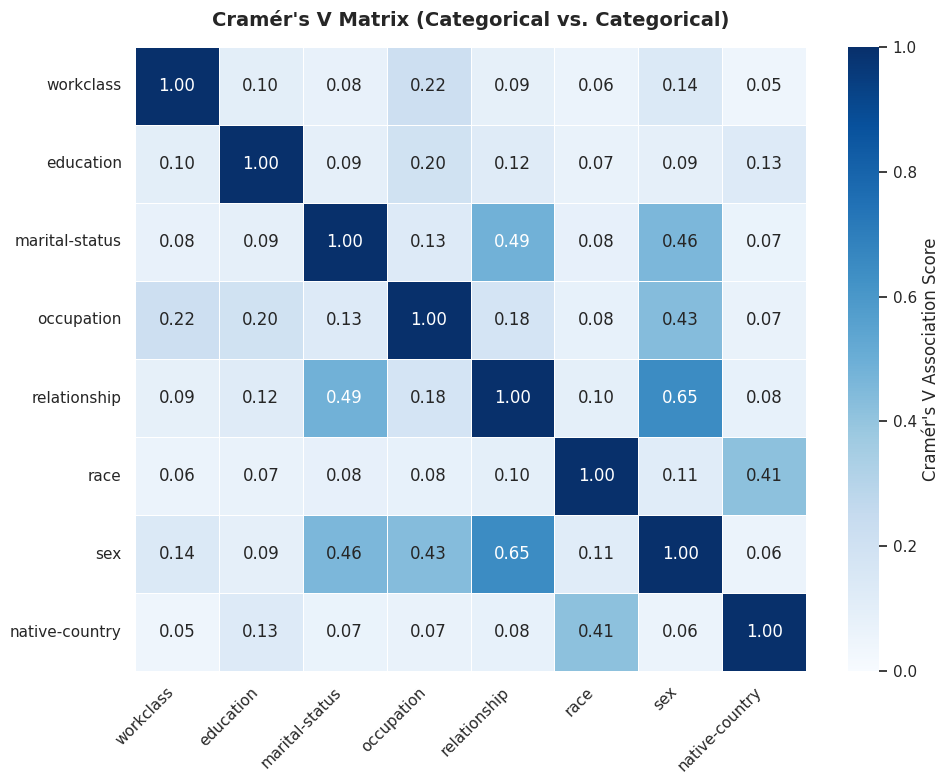

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

def compute_cramers_v_matrix(df):
    # Select categorical columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns

    # Initialize an empty DataFrame for the results matrix
    cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

    for col1 in cat_cols:
        for col2 in cat_cols:
            if col1 == col2:
                cramers_matrix.loc[col1, col2] = 1.0
            else:
                # Create contingency table
                contingency_table = pd.crosstab(df[col1], df[col2])
                chi2 = stats.chi2_contingency(contingency_table)[0]
                n = contingency_table.sum().sum()
                r, k = contingency_table.shape

                # Prevent division by zero if a column has only 1 unique value
                if min(r, k) <= 1:
                    v = 0.0
                else:
                    v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

                cramers_matrix.loc[col1, col2] = v

    return cramers_matrix

# 1. Compute the Cramér's V matrix
cramers_df = compute_cramers_v_matrix(df_cleaned)

# Display the numerical table
print("--- Cramér's V Association Matrix ---")
print(cramers_df.round(2))

# 2. Plot the Heatmap for intuitive interpretation
plt.figure(figsize=(10, 8))
sns.heatmap(
    cramers_df,
    annot=True,
    fmt=".2f",
    cmap='Blues',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': "Cramér's V Association Score"}
)

plt.title("Cramér's V Matrix (Categorical vs. Categorical)", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Cramér's V Analysis

The Cramér's V analysis identified several strongly associated categorical variables, particularly `relationship` with `sex` ($V = 0.65$) and `marital-status` with `relationship` ($V = 0.49$). These associations indicate potential feature redundancy, particularly among demographic and household-related variables.

However, no variables are removed at this stage because association alone does not establish that a feature is unnecessary for prediction. Feature redundancy will instead be evaluated during the subsequent modeling and feature-selection stages.

### Feature Redundancy Evaluation Plan

```text
Model A:
    All features

Model B:
    Remove relationship

Model C:
    Remove marital-status

Model D:
    Remove sex
```

The models will then be compared using the same evaluation methodology to determine whether removing a potentially redundant feature affects predictive performance.


##Numerical to Categorical

--- Correlation Ratio (η) Matrix: Numerical vs. Categorical ---
                workclass  education  marital-status  occupation  \
age                  0.23       0.24            0.58        0.19   
fnlwgt               0.05       0.06            0.05        0.05   
education-num        0.19       1.00            0.11        0.57   
capital-gain         0.11       0.20            0.08        0.12   
capital-loss         0.04       0.10            0.08        0.08   
hours-per-week       0.16       0.19            0.25        0.27   
income               0.16       0.37            0.45        0.35   

                relationship  race   sex  native-country  
age                     0.47  0.04  0.09            0.09  
fnlwgt                  0.04  0.15  0.03            0.15  
education-num           0.16  0.11  0.01            0.28  
capital-gain            0.09  0.02  0.05            0.03  
capital-loss            0.08  0.03  0.05            0.04  
hours-per-week          0.31  0.05  0

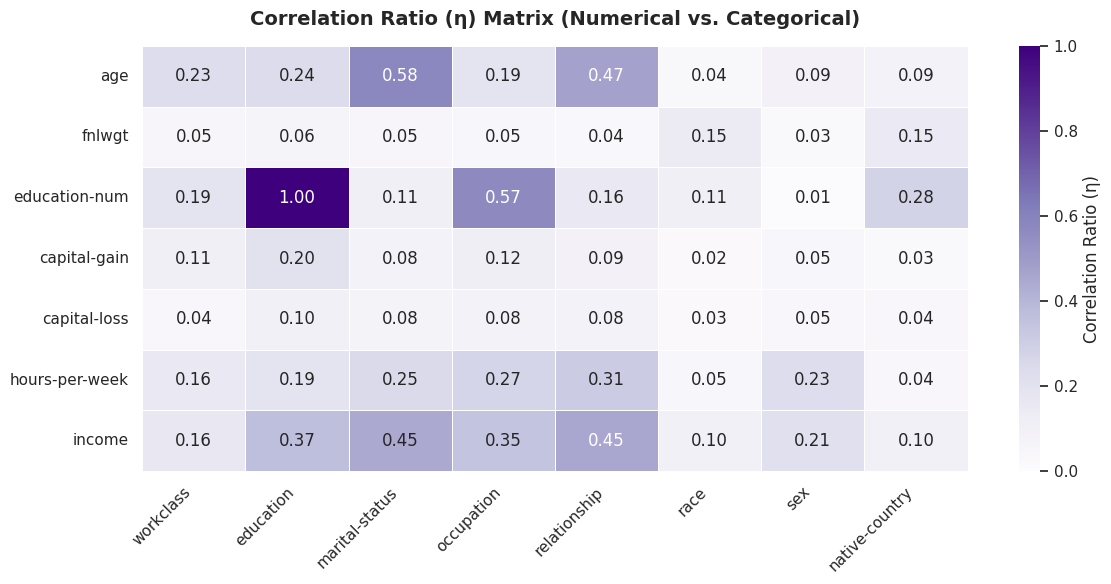

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def compute_eta(categories, measurements):
    """
    Computes the correlation ratio (Eta) between a categorical and a numerical variable.
    """
    # Convert categories to numeric codes
    fcat, _ = pd.factorize(categories)
    cat_classes = np.unique(fcat)

    y_mean = np.mean(measurements)
    ss_total = np.sum((measurements - y_mean) ** 2)

    if ss_total == 0:
        return 0.0

    ss_between = 0
    for cat in cat_classes:
        group_vals = measurements[fcat == cat]
        n_k = len(group_vals)
        if n_k > 0:
            group_mean = np.mean(group_vals)
            ss_between += n_k * (group_mean - y_mean) ** 2

    return np.sqrt(ss_between / ss_total)

# 1. Select columns by type
num_cols = df_cleaned.select_dtypes(include=['number']).columns
cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns

# 2. Build a summary DataFrame (Rows: Numerical, Columns: Categorical)
eta_matrix = pd.DataFrame(index=num_cols, columns=cat_cols, dtype=float)

for num in num_cols:
    for cat in cat_cols:
        # Drop rows with missing values for clean calculation
        subset = df_cleaned[[num, cat]].dropna()
        eta_val = compute_eta(subset[cat], subset[num])
        eta_matrix.loc[num, cat] = eta_val

# Display the numerical table
print("--- Correlation Ratio (η) Matrix: Numerical vs. Categorical ---")
print(eta_matrix.round(2))

# 3. Plot the Heatmap for easy visual interpretation
plt.figure(figsize=(12, 6))
sns.heatmap(
    eta_matrix,
    annot=True,
    fmt=".2f",
    cmap='Purples',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Ratio (η)'}
)

plt.title("Correlation Ratio (η) Matrix (Numerical vs. Categorical)", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Feature Removal Plan

The association analysis identified several groups of variables with strong relationships. However, a strong association does not automatically mean that a feature should be removed. Feature removal will therefore be performed selectively and validated through model performance.

##### 1. Remove `education` or `education-num`

The Correlation Ratio analysis shows:

- `education` ↔ `education-num`: **η = 1.00**

`education-num` is a numerical representation of `education`, meaning that both variables contain essentially the same information.

Therefore, one of them should be removed to avoid redundant information.

**Plan:**

- **Model A:** Keep `education` + `education-num`
- **Model B:** Remove `education`
- **Model C:** Remove `education-num`

The three models can then be compared using the same cross-validation procedure.

##### 2. Investigate `relationship`, `marital-status`, and `sex`

The Cramér's V analysis identified strong associations:

- `relationship` ↔ `sex`: **V = 0.65**
- `marital-status` ↔ `relationship`: **V = 0.49**
- `marital-status` ↔ `sex`: **V = 0.46**

These variables may contain overlapping demographic information.

**Plan:**

- **Model D:** Keep all three variables
- **Model E:** Remove `relationship`
- **Model F:** Remove `marital-status`
- **Model G:** Remove `sex`

##### 3. Keep `workclass` and `occupation` initially

The association between:

- `workclass` ↔ `occupation`: **V = 0.40**

is moderate. Although the variables are related, they represent different concepts.

Therefore, both should initially be retained and evaluated by the model.

##### 4. Keep weakly associated variables initially

Variables such as `fnlwgt` and `capital-loss` show relatively weak associations with most categorical variables.

However, weak association does **not** necessarily mean that a feature has no predictive value.

Therefore, these features should not be removed based only on the association analysis.

##### 5. Final Validation Strategy

The final decision will be based on model performance rather than association thresholds alone.

The comparison will use the same preprocessing, cross-validation strategy, and evaluation metrics for every model.

| Model | Feature Modification |
|---|---|
| **Model A** | All features |
| **Model B** | Remove `education` |
| **Model C** | Remove `education-num` |
| **Model D** | Remove `relationship` |
| **Model E** | Remove `marital-status` |
| **Model F** | Remove `sex` |
| **Model G** | Remove selected redundant features |

> **Key conclusion:** Feature removal will be based on both statistical association and empirical model performance. A high association is treated as a signal for investigation, not as an automatic reason for deletion.

#cleaning

In [ ]:
import pandas as pd
import numpy as np

def clean_adult_data(df):
    # 1. Standardize missing value placeholders ('?') to NaN
    df = df.replace(' ?', np.nan).replace('?', np.nan)

    # 2. Strip whitespace from all string/object columns
    string_cols = df.select_dtypes(include=['object']).columns
    for col in string_cols:
        df[col] = df[col].str.strip()

    # 3. Clean target variable formatting (handling trailing periods if present)
    if 'income' in df.columns:
        df['income'] = df['income'].str.replace('.', '', regex=False)
        df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

    # 4. Drop redundant or non-predictive columns
    # 'fnlwgt' is a sampling weight typically dropped in ML tasks
    # 'education' is already numerically encoded by 'education-num'
    cols_to_drop = [col for col in ['fnlwgt', 'education'] if col in df.columns]
    df = df.drop(columns=cols_to_drop)

    # 5. Handle missing values in categorical columns
    # Impute with a dedicated 'Unknown' category or mode
    categorical_with_nas = ['workclass', 'occupation', 'native-country']
    for col in categorical_with_nas:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')

    return df

# Usage example:
# df_cleaned = clean_adult_data(df_raw)

In [ ]:
df_cleaned = clean_adult_data(df)

#Feature engineering

In [ ]:
import pandas as pd
import numpy as np

def engineer_adult_features(df):
    df = df.copy()

    # 1. Net Capital & Signed Log Transformation
    if 'capital-gain' in df.columns and 'capital-loss' in df.columns:
        net_capital = df['capital-gain'] - df['capital-loss']
        df['net-capital-log'] = np.sign(net_capital) * np.log1p(np.abs(net_capital))
        df = df.drop(columns=['capital-gain', 'capital-loss'])

    # 2. Age Bins: Group ages into meaningful life-stage categories
    if 'age' in df.columns:
        bins = [0, 25, 45, 65, 100]
        labels = ['Young', 'Adult', 'Middle-Aged', 'Senior']
        df['age-group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

    # 3. Work Intensity: Categorize hours worked per week
    if 'hours-per-week' in df.columns:
        df['work-intensity'] = pd.cut(
            df['hours-per-week'],
            bins=[0, 39, 40, 168],
            labels=['Part-Time', 'Full-Time', 'Overtime'],
            right=True
        )

    # 4. Native Country Tiers: Collapse high-cardinality countries into economic tiers
    if 'native-country' in df.columns:
        native_country_mapping = {
            # Domestic Majority
            'United-States': 'US_Dominant',

            # Advanced / High-Income Economies
            'Canada': 'Advanced_West', 'Germany': 'Advanced_West', 'England': 'Advanced_West',
            'France': 'Advanced_West', 'Italy': 'Advanced_West', 'Japan': 'Advanced_West',
            'Taiwan': 'Advanced_West', 'Ireland': 'Advanced_West', 'Hong': 'Advanced_West',
            'Holand-Netherlands': 'Advanced_West', 'Scotland': 'Advanced_West', 'Greece': 'Advanced_West',
            'Portugal': 'Advanced_West', 'Puerto-Rico': 'Advanced_West',

            # Developing & Emerging Economies
            'Mexico': 'Developing_Emerging', 'Poland': 'Developing_Emerging', 'Hungary': 'Developing_Emerging',
            'Yugoslavia': 'Developing_Emerging', 'Iran': 'Developing_Emerging', 'Cuba': 'Developing_Emerging',
            'Jamaica': 'Developing_Emerging', 'Peru': 'Developing_Emerging', 'Ecuador': 'Developing_Emerging',
            'Columbia': 'Developing_Emerging', 'China': 'Developing_Emerging', 'Thailand': 'Developing_Emerging',
            'Trinadad&Tobago': 'Developing_Emerging', 'Philippines': 'Developing_Emerging', 'India': 'Developing_Emerging',
            'Dominican-Republic': 'Developing_Emerging', 'El-Salvador': 'Developing_Emerging', 'Guatemala': 'Developing_Emerging',
            'Nicaragua': 'Developing_Emerging', 'Vietnam': 'Developing_Emerging', 'Honduras': 'Developing_Emerging',
            'Outlying-US(Guam-USVI-etc)': 'Developing_Emerging', 'South': 'Developing_Emerging', 'Cambodia': 'Developing_Emerging',
            'Laos': 'Developing_Emerging', 'Haiti': 'Developing_Emerging',

            # Missing / Unknown Data
            'Unknown': 'Unknown',
            np.nan: 'Unknown',
            '?': 'Unknown'
        }

        df['native-country-tier'] = df['native-country'].map(native_country_mapping).fillna('Unknown')
        df = df.drop(columns=['native-country'])

    # 5. Race Grouping: Collapse low-frequency categories to prevent sparse features
    if 'race' in df.columns:
        race_mapping = {
            'White': 'White',
            'Black': 'Black',
            'Asian-Pac-Islander': 'Other',
            'Amer-Indian-Eskimo': 'Other',
            'Other': 'Other',
            'Unknown': 'Other',
            np.nan: 'Other',
            '?': 'Other'
        }
        df['race-grouped'] = df['race'].map(race_mapping).fillna('Other')
        df = df.drop(columns=['race'])

    return df


In [ ]:
fe = engineer_adult_features(df_cleaned)
fe.head()

,age,workclass,education-num,marital-status,occupation,relationship,sex,hours-per-week,income,net-capital-log,age-group,work-intensity,native-country-tier,race-grouped
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,Male,40,0,7.684784,Adult,Full-Time,US_Dominant,White
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,Male,13,0,0.000000,Middle-Aged,Part-Time,US_Dominant,White
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,Male,40,0,0.000000,Adult,Full-Time,US_Dominant,White
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,40,0,0.000000,Middle-Aged,Full-Time,US_Dominant,Black
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Female,40,0,0.000000,Adult,Full-Time,Developing_Emerging,Black


#Training

##Supervised Learning

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# 1. Separate features and target
X = fe.drop(columns=['income'])
y = fe['income']

# 2. Identify column types for the transformer
numeric_features = ['age', 'education-num', 'hours-per-week', 'net-capital-log']
categorical_features = [
    'workclass', 'marital-status', 'occupation', 'relationship',
    'sex', 'age-group', 'work-intensity',
]

# 3. Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 4. Build the full pipeline with a Random Forest classifier (or swap for XGBoost/LightGBM)
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
    ]
)

# 5. Train-test split and fit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline.fit(X_train, y_train)

# 6. Evaluate
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ROC-AUC Score: 0.888604934430119

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.90      0.89      7431
           1       0.67      0.65      0.66      2338

    accuracy                           0.84      9769
   macro avg       0.78      0.77      0.78      9769
weighted avg       0.84      0.84      0.84      9769



In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# 1. Define the dictionary of classifiers to evaluate (including XGBoost)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=42
    )
    }

# 2. Set up cross-validation and metrics
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'accuracy', 'f1']

# 3. Iterate through models and store results
results_summary = []

for name, model in models.items():
    print(f"Training and evaluating: {name}...")

    # Create a pipeline with the current model
    current_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Run cross-validation
    cv_results = cross_validate(current_pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    # Record mean scores
    results_summary.append({
        'Model': name,
        'Mean ROC-AUC': cv_results['test_roc_auc'].mean(),
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Mean F1-Score': cv_results['test_f1'].mean()
    })

# 4. Compile into a DataFrame and sort by ROC-AUC
results_df = pd.DataFrame(results_summary).sort_values(by='Mean ROC-AUC', ascending=False).reset_index(drop=True)

print("\n--- Model Comparison Results ---")
print(results_df.to_markdown(index=False))

Training and evaluating: Logistic Regression...
Training and evaluating: Random Forest...


KeyboardInterrupt: 

colinearity findings

In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

# 1. Ensure X contains all engineered features
fe= engineer_adult_features(df_cleaned)
X_all = fe.drop(columns=['income'])
y = fe['income']

# 2. Define the feature variants based on your plan
feature_variants = {
    "Model A (All Features)": X_all.columns.tolist(),
    "Model B (Remove relationship)": [col for col in X_all.columns if col != 'relationship'],
    "Model C (Remove marital-status)": [col for col in X_all.columns if col != 'marital-status'],
    "Model D (Remove sex)": [col for col in X_all.columns if col != 'sex']
}

# 3. Set up cross-validation and evaluation metrics
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'accuracy', 'f1']

redundancy_results = []

# 4. Evaluate each variant using a robust classifier (e.g., XGBoost)
for name, cols in feature_variants.items():
    print(f"Evaluating {name} ({len(cols)} features)...")

    # Subset data for this variant
    X_subset = X_all[cols]

    # Dynamically update numerical/categorical feature lists for the preprocessor
    current_num_features = [c for c in numeric_features if c in cols]
    current_cat_features = [c for c in categorical_features if c in cols]

    # Re-instantiate preprocessor for the current subset of columns
    current_preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), current_num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), current_cat_features)
        ]
    )

    # Build pipeline
    current_pipeline = Pipeline(steps=[
        ('preprocessor', current_preprocessor),
        ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric='logloss', random_state=42, n_jobs=-1))
    ])

    # Run cross-validation
    cv_results = cross_validate(current_pipeline, X_subset, y, cv=cv, scoring=scoring, n_jobs=-1)

    # Record scores
    redundancy_results.append({
        'Variant': name,
        'Num Features': len(cols),
        'Mean ROC-AUC': cv_results['test_roc_auc'].mean(),
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Mean F1-Score': cv_results['test_f1'].mean()
    })

# 5. Compile and display comparison
redundancy_df = pd.DataFrame(redundancy_results).sort_values(by='Mean ROC-AUC', ascending=False).reset_index(drop=True)

print("\n--- Feature Redundancy Evaluation Results ---")
print(redundancy_df.to_markdown(index=False))

Evaluating Model A (All Features) (13 features)...
Evaluating Model B (Remove relationship) (12 features)...
Evaluating Model C (Remove marital-status) (12 features)...
Evaluating Model D (Remove sex) (12 features)...

--- Feature Redundancy Evaluation Results ---
| Variant                         |   Num Features |   Mean ROC-AUC |   Mean Accuracy |   Mean F1-Score |
|:--------------------------------|---------------:|---------------:|----------------:|----------------:|
| Model A (All Features)          |             13 |       0.929199 |        0.873695 |        0.709332 |
| Model B (Remove relationship)   |             12 |       0.929068 |        0.874288 |        0.710084 |
| Model D (Remove sex)            |             12 |       0.928795 |        0.87347  |        0.708322 |
| Model C (Remove marital-status) |             12 |       0.928516 |        0.873265 |        0.708197 |


In [ ]:
import pandas as pd
import joblib  # Used for saving the trained pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

# 1. Ensure X contains all engineered features
X_all = fe.drop(columns=['income'])
y = fe['income']

# Define feature groups (ensuring they match your engineering setup)
numeric_features = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']
categorical_features = [
    'workclass', 'occupation', 'sex', 'relationship',
    'age-group', 'work-intensity', 'native-country-tier', 'race-grouped'
]

# 2. Define the feature variants based on your plan
feature_variants = {
    "Model A (All Features)": X_all.columns.tolist(),
    "Model B (Remove relationship)": [col for col in X_all.columns if col != 'relationship'],
    "Model C (Remove marital-status)": [col for col in X_all.columns if col != 'marital-status'],
    "Model D (Remove sex)": [col for col in X_all.columns if col != 'sex']
}

# 3. Set up cross-validation and evaluation metrics
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'accuracy', 'f1']

redundancy_results = []
best_score = -1
best_variant_name = None
best_pipeline = None

# 4. Evaluate each variant using a robust classifier (e.g., XGBoost)
for name, cols in feature_variants.items():
    print(f"Evaluating {name} ({len(cols)} features)...")

    # Subset data for this variant
    X_subset = X_all[cols]

    # Dynamically update numerical/categorical feature lists for the preprocessor
    current_num_features = [c for c in numeric_features if c in cols]
    current_cat_features = [c for c in categorical_features if c in cols]

    # Re-instantiate preprocessor for the current subset of columns
    current_preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), current_num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), current_cat_features)
        ]
    )

    # Build pipeline
    current_pipeline = Pipeline(steps=[
        ('preprocessor', current_preprocessor),
        ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric='logloss', random_state=42, n_jobs=-1))
    ])

    # Run cross-validation
    cv_results = cross_validate(current_pipeline, X_subset, y, cv=cv, scoring=scoring, n_jobs=-1)
    mean_roc_auc = cv_results['test_roc_auc'].mean()

    # Track and fit the best performing model
    if mean_roc_auc > best_score:
        best_score = mean_roc_auc
        best_variant_name = name
        # Fit the pipeline on the full dataset subset for deployment/inference usage
        best_pipeline = current_pipeline.fit(X_subset, y)

    # Record scores
    redundancy_results.append({
        'Variant': name,
        'Num Features': len(cols),
        'Mean ROC-AUC': mean_roc_auc,
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Mean F1-Score': cv_results['test_f1'].mean()
    })

# 5. Compile and display comparison
redundancy_df = pd.DataFrame(redundancy_results).sort_values(by='Mean ROC-AUC', ascending=False).reset_index(drop=True)

print("\n--- Feature Redundancy Evaluation Results ---")
print(redundancy_df.to_markdown(index=False))

print(f"\n🏆 Best Model Identified: {best_variant_name} (ROC-AUC: {best_score:.4f})")

# 6. Save the best fitted model to disk
model_filename = "best_adult_xgboost_model.pkl"
joblib.dump(best_pipeline, model_filename)
print(f"Model successfully saved to disk as '{model_filename}'")

##Unupervised Learning

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Prepare features for Model C (drop income and marital-status)
cols_to_drop = ['income', 'marital-status']
X = fe.drop(columns=[col for col in cols_to_drop if col in fe.columns])

# 2. Define feature lists
numeric_features = [
    'age', 'education-num', 'hours-per-week',
    'capital-gain-log', 'capital-loss-log'
]
categorical_features = [
    'workclass', 'occupation', 'sex', 'relationship',
    'age-group', 'work-intensity', 'native-country-tier', 'race-grouped'
]

numeric_features = [col for col in numeric_features if col in X.columns]
categorical_features = [col for col in categorical_features if col in X.columns]

# 3. Preprocess the data into a dense matrix
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

print("Transforming features for clustering...")
X_transformed = preprocessor.fit_transform(X)

# 4. Run Elbow & Silhouette analysis across a range of k values
k_range = range(2, 10)
inertias = []
silhouette_scores = []

# Take a random sample for silhouette calculation to speed things up
sample_size = min(5000, X_transformed.shape[0])
rng = np.random.default_rng(42)
sample_indices = rng.choice(X_transformed.shape[0], size=sample_size, replace=False)
X_sample = X_transformed[sample_indices]

for k in k_range:
    print(f"Evaluating k = {k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_transformed)

    # Elbow method metric: Inertia (within-cluster sum of squares)
    inertias.append(kmeans.inertia_)

    # Silhouette score metric (evaluated on the sample)
    sample_labels = cluster_labels[sample_indices]
    score = silhouette_score(X_sample, sample_labels)
    silhouette_scores.append(score)

# 5. Compile results into a summary table
cluster_results = pd.DataFrame({
    'Clusters (k)': list(k_range),
    'Inertia': inertias,
    'Silhouette Score': silhouette_scores
})

print("\n--- Clustering Evaluation Results ---")
print(cluster_results.to_markdown(index=False))

# 6. Plotting the results
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Elbow Method)', color=color)
ax1.plot(k_range, inertias, marker='o', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_scores, marker='s', color=color, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method and Silhouette Analysis for K-Means')
fig.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.cluster import KMeans
from xgboost import XGBClassifier

# 1. Prepare base features for Model C (drop income and marital-status)
cols_to_drop = ['income', 'marital-status']
X_base = fe.drop(columns=[col for col in cols_to_drop if col in fe.columns])
y = fe['income']

# 2. Define feature groups matching df_engineered columns exactly
numeric_features = [
    'age', 'education-num', 'hours-per-week',
    'capital-gain-log', 'capital-loss-log'
]
categorical_features = [
    'workclass', 'occupation', 'sex', 'relationship',
    'age-group', 'work-intensity', 'native-country-tier', 'race-grouped'
]

# Keep only columns that actually exist in X_base
numeric_features = [col for col in numeric_features if col in X_base.columns]
categorical_features = [col for col in categorical_features if col in X_base.columns]

# 3. Transform base features to run K-Means clustering
preprocessor_cluster = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

print("Preprocessing features for clustering search...")
X_transformed = preprocessor_cluster.fit_transform(X_base)

# 4. Search across k from 2 to 5
k_options = [2, 3, 4, 5]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search_results = []

for k in k_options:
    print(f"Evaluating model performance with k = {k} clusters...")

    # Generate cluster labels
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_transformed)

    # Append cluster label as a new categorical feature
    X_augmented = X_base.copy()
    X_augmented['cluster_id'] = pd.Categorical(cluster_labels)

    # Update categorical features list to include cluster_id
    current_cat_features = categorical_features + ['cluster_id']

    # Preprocessor for augmented feature space
    current_preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), current_cat_features)
        ]
    )

    # XGBoost pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', current_preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ))
    ])

    # Cross-validate
    cv_results = cross_validate(pipeline, X_augmented, y, cv=cv, scoring=['roc_auc', 'accuracy', 'f1'], n_jobs=-1)

    search_results.append({
        'Clusters (k)': k,
        'Mean ROC-AUC': cv_results['test_roc_auc'].mean(),
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Mean F1-Score': cv_results['test_f1'].mean()
    })

# 5. Display Leaderboard
results_df = pd.DataFrame(search_results).sort_values(by='Mean ROC-AUC', ascending=False).reset_index(drop=True)

print("\n--- Cluster Feature Performance Leaderboard ---")
print(results_df.to_markdown(index=False))

#PCA

In [ ]:
# Pure continuous features for the PCA branch
pca_numeric_features = [
    'age',
    'education-num',
    'hours-per-week',
    'net-capital-log'
]

# Extract these directly from df_engineered (ensuring they weren't dropped)
X_num_pca = fe[[col for col in pca_numeric_features if col in fe.columns]]

In [ ]:
import pandas as pd
import numpy as np

def engineer_adult_features_pca(df):
    df = df.copy()

    # 1. Net Capital & Signed Log Transformation
    if 'capital-gain' in df.columns and 'capital-loss' in df.columns:
        net_capital = df['capital-gain'] - df['capital-loss']
        df['net-capital-log'] = np.sign(net_capital) * np.log1p(np.abs(net_capital))
        df = df.drop(columns=['capital-gain', 'capital-loss'])



    # 4. Native Country Tiers: Collapse high-cardinality countries into economic tiers
    if 'native-country' in df.columns:
        native_country_mapping = {
            # Domestic Majority
            'United-States': 'US_Dominant',

            # Advanced / High-Income Economies
            'Canada': 'Advanced_West', 'Germany': 'Advanced_West', 'England': 'Advanced_West',
            'France': 'Advanced_West', 'Italy': 'Advanced_West', 'Japan': 'Advanced_West',
            'Taiwan': 'Advanced_West', 'Ireland': 'Advanced_West', 'Hong': 'Advanced_West',
            'Holand-Netherlands': 'Advanced_West', 'Scotland': 'Advanced_West', 'Greece': 'Advanced_West',
            'Portugal': 'Advanced_West', 'Puerto-Rico': 'Advanced_West',

            # Developing & Emerging Economies
            'Mexico': 'Developing_Emerging', 'Poland': 'Developing_Emerging', 'Hungary': 'Developing_Emerging',
            'Yugoslavia': 'Developing_Emerging', 'Iran': 'Developing_Emerging', 'Cuba': 'Developing_Emerging',
            'Jamaica': 'Developing_Emerging', 'Peru': 'Developing_Emerging', 'Ecuador': 'Developing_Emerging',
            'Columbia': 'Developing_Emerging', 'China': 'Developing_Emerging', 'Thailand': 'Developing_Emerging',
            'Trinadad&Tobago': 'Developing_Emerging', 'Philippines': 'Developing_Emerging', 'India': 'Developing_Emerging',
            'Dominican-Republic': 'Developing_Emerging', 'El-Salvador': 'Developing_Emerging', 'Guatemala': 'Developing_Emerging',
            'Nicaragua': 'Developing_Emerging', 'Vietnam': 'Developing_Emerging', 'Honduras': 'Developing_Emerging',
            'Outlying-US(Guam-USVI-etc)': 'Developing_Emerging', 'South': 'Developing_Emerging', 'Cambodia': 'Developing_Emerging',
            'Laos': 'Developing_Emerging', 'Haiti': 'Developing_Emerging',

            # Missing / Unknown Data
            'Unknown': 'Unknown',
            np.nan: 'Unknown',
            '?': 'Unknown'
        }

        df['native-country-tier'] = df['native-country'].map(native_country_mapping).fillna('Unknown')
        df = df.drop(columns=['native-country'])

    # 5. Race Grouping: Collapse low-frequency categories to prevent sparse features
    if 'race' in df.columns:
        race_mapping = {
            'White': 'White',
            'Black': 'Black',
            'Asian-Pac-Islander': 'Other',
            'Amer-Indian-Eskimo': 'Other',
            'Other': 'Other',
            'Unknown': 'Other',
            np.nan: 'Other',
            '?': 'Other'
        }
        df['race-grouped'] = df['race'].map(race_mapping).fillna('Other')
        df = df.drop(columns=['race'])

    return df


In [ ]:
print(X_num_pca)

In [ ]:
y = fe['income']
print(y)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score

# Assuming raw data is in `df` and you ran your engineer_adult_features(df)
#df_engineered = engineer_adult_features(df)
df_engineered = df
y = fe['income']

# --- STEP 1: PCA on Pure Continuous Numerical Features ---
pca_numeric_features = ['age', 'education-num', 'hours-per-week', 'capital-gain','capital-loss']
X_num = df_engineered[[col for col in pca_numeric_features if col in df_engineered.columns]]

# Fit full PCA to inspect the Scree / Elbow plot
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

pca_full = PCA(random_state=42)
pca_full.fit(X_num_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Explained Variance': explained_variance,
    'Cumulative Variance': cumulative_variance,
})
print("--- PCA Explained Variance Breakdown ---")
print(pca_summary.to_markdown(index=False))




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Prepare raw numerical features
pca_numeric_features = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']
X_num = df_engineered[[col for col in pca_numeric_features if col in df_engineered.columns]]

# 2. Standardize
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# 3. Fit PCA
pca = PCA(random_state=42)
pca.fit(X_num_scaled)

eigenvalues = pca.explained_variance_

# --- TEST 1: Eigenvalue Table ---
eigenvalue_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Eigenvalue': eigenvalues,
    'Explained Variance (%)': pca.explained_variance_ratio_ * 100,
    'Kaiser Rule (>1.0)': eigenvalues > 1.0
})
print("--- Eigenvalue Test (Kaiser Criterion) ---")
print(eigenvalue_df.to_markdown(index=False))

# --- TEST 2: Scree Plot & Elbow Test ---
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-', color='tab:blue', linewidth=2, markersize=8)
plt.axhline(y=1.0, color='tab:red', linestyle='--', label='Kaiser Threshold (Eigenvalue = 1.0)')
plt.title('Scree Plot & Eigenvalue Analysis')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.xticks(range(1, len(eigenvalues) + 1))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

# --- TEST 3: Correlation Circle (PC1 vs PC2) ---
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(6, 6))
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)

circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='solid', linewidth=1.5)
plt.gca().add_patch(circle)

for i, var_name in enumerate(X_num.columns):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], head_width=0.03, head_length=0.05, fc='tab:blue', ec='tab:blue')
    plt.text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15, var_name, color='darkred', ha='center', va='center', fontweight='bold')

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.title(f'Correlation Circle (PC1 vs PC2)\nPC1: {pca.explained_variance_ratio_[0]*100:.1f}% | PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

# 1. Apply your feature engineering function
# (Assumes 'df' is your loaded raw adult dataframe)
df_engineered = engineer_adult_features_pca(df)

# 2. Prepare Features and Target
cols_to_drop = ['income'] # Add any other columns you want to drop globally if needed
X = df_engineered.drop(columns=[col for col in cols_to_drop if col in df_engineered.columns])
y = df_engineered['income'].apply(lambda val: 1 if val == '>50K' else 0)

# 3. Define feature groups matching the new engineering output
# Note: 'capital-gain' and 'capital-loss' are replaced by 'net-capital-log'
pca_numeric_features = ['age', 'education-num', 'hours-per-week', 'net-capital-log']

categorical_features = [
    'workclass', 'occupation', 'sex', 'relationship',
    'marital-status', 'native-country-tier', 'race-grouped'
]

# Filter to ensure columns exist in dataframe
pca_numeric_features = [col for col in pca_numeric_features if col in X.columns]
categorical_features = [col for col in categorical_features if col in X.columns]

# 4. Create a sub-pipeline for Numerical features: Scale -> PCA (n=3)
numerical_pca_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=42))
])

# 5. Combine PCA numerical branch and One-Hot categorical branch side-by-side
preprocessor = ColumnTransformer(
    transformers=[
        ('num_pca', numerical_pca_pipeline, pca_numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 6. Full Pipeline integrating XGBoost
xgb_pca_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# 7. Evaluate via 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    xgb_pca_pipeline, X, y,
    cv=cv,
    scoring=['roc_auc', 'accuracy', 'f1'],
    n_jobs=-1
)

# 8. Print Performance Summary
print("--- XGBoost on PCA Features (with net-capital-log) + One-Hot Categoricals ---")
print(f"Mean ROC-AUC:  {cv_results['test_roc_auc'].mean():.4f} (± {cv_results['test_roc_auc'].std():.4f})")
print(f"Mean Accuracy: {cv_results['test_accuracy'].mean():.4f} (± {cv_results['test_accuracy'].std():.4f})")
print(f"Mean F1-Score: {cv_results['test_f1'].mean():.4f}")

In [ ]:
models